# Following splink's example, for the synthetic dataset

We follow the steps done in 

`https://moj-analytical-services.github.io/splink/demos/examples/duckdb/transactions.html`

while adapting the datasets for the synthetic dataset.

In [1]:
from splink import DuckDBAPI, Linker, SettingsCreator, block_on, splink_datasets
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import os

import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))  # Add parent directory

df1_path = os.path.join("..", "..", "output_data", "smallestest_dataset_a.parquet")
df2_path = os.path.join("..", "..", "output_data", "smallestest_dataset_b.parquet")


df1 = pd.read_parquet(df1_path)
df2 = pd.read_parquet(df2_path)

display(df1.head(2))
display(df2.head(2))

,global_entity_id,local_source_id,categorical,numerical_noisy,datetime_noisy,latent_event_id
0,100073,DF1_100073,CAT_1,722.39,2025-12-31 22:01:11.513018628,OVER_1
1,100073,DF1_100073,CAT_5,655.69,2026-01-01 01:44:35.403874141,OVER_0


,global_entity_id,local_source_id,categorical,numerical_noisy,datetime_noisy,latent_event_id
0,100061,DF2_100061,CAT_5,174.62,2025-12-31 20:08:26.958665506,UNIQ_B_1332
1,100073,DF1_100073,None,651.94,2025-12-31 20:45:09.641651976,OVER_0


#### Checking the distributin of numerical_noisy

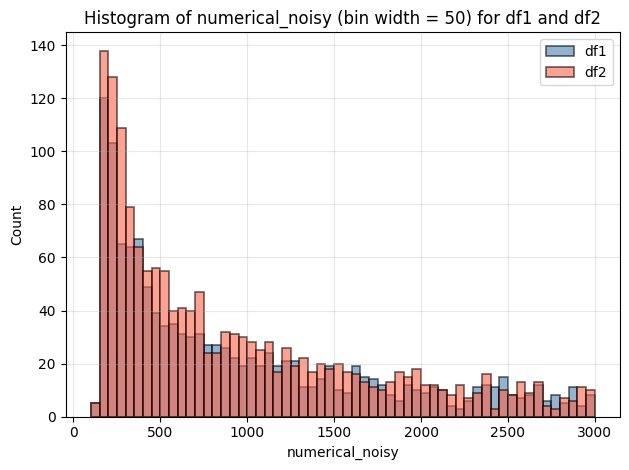

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Drop NaNs once so we reuse the clean series
df1_clean = df1['numerical_noisy'].dropna()
df2_clean = df2['numerical_noisy'].dropna()

# Choose bin edges that span the combined range with a width of 50
min_val = min(df1_clean.min(), df2_clean.min())
max_val = max(df1_clean.max(), df2_clean.max())
bins = np.arange(np.floor(min_val / 50) * 50,
                 np.ceil (max_val / 50) * 50 + 50,  # +50 to make the last bin inclusive
                 50)

# Plot histograms (alpha lets you see overlap)
df1_clean.plot(kind='hist',
               bins=bins,
               density=False,          # change to True if you want a probability density
               alpha=0.6,
               label='df1',
               color='steelblue',
               edgecolor='black',
               linewidth=1.2)

df2_clean.plot(kind='hist',
               bins=bins,
               density=False,
               alpha=0.6,
               label='df2',
               color='tomato',
               edgecolor='black',
               linewidth=1.2)

# Titles / labels / legend / grid – unchanged from your original snippet
plt.title('Histogram of numerical_noisy (bin width = 50) for df1 and df2')
plt.xlabel('numerical_noisy')
plt.ylabel('Count')          # use 'Density' if you set density=True above
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Preprocessing and data profiling

In [3]:
# Remove the time portion in dataset B -> we essentially reset of midnight.
# TODO(steven): We probably would need to think of a better way to handle the time. Setting to midnight might not be the best.
df1['datetime_noisy'] = df1['datetime_noisy'].dt.floor('D')
df2['datetime_noisy'] = df2['datetime_noisy'].dt.floor('D')

# Converting to seconds since epoch for splink compatibility
# df1["datetime_noisy"] = pd.to_datetime(df1["datetime_noisy"]).astype("int64") // 10**9
# df2["datetime_noisy"] = pd.to_datetime(df2["datetime_noisy"]).astype("int64") // 10**9
df1

,global_entity_id,local_source_id,categorical,numerical_noisy,datetime_noisy,latent_event_id
0,100073,DF1_100073,CAT_1,722.39,2025-12-31,OVER_1
1,100073,DF1_100073,CAT_5,655.69,2026-01-01,OVER_0
2,100076,DF1_100076,CAT_2,NaN,2026-01-01,UNI_A_126
3,100081,DF1_100081,CAT_1,350.00,2026-01-01,UNI_A_127
4,100000,DF1_100000,CAT_6,1145.84,2026-01-01,UNI_A_128
...,...,...,...,...,...,...
1327,100029,DF1_100029,CAT_1,147.28,2026-05-31,UNI_A_1327
1328,100003,DF1_100003,CAT_3,1028.96,2026-05-31,UNI_A_1328
1329,100020,DF1_100020,CAT_1,537.59,2026-05-31,UNI_A_1329
1330,100001,DF1_100001,CAT_7,380.71,2026-06-01,UNI_A_1330


In [5]:
from splink.exploratory import profile_columns
import duckdb

con = duckdb.connect()

# 2. Hard-cap the RAM allocation (e.g., limit it to 4 Gigabytes)
con.execute("SET memory_limit = '24GB';")

# 3. Explicitly define where intermediate results should spill on your hard drive
con.execute("SET temp_directory = './duckdb_spill_dir.tmp';")

db_api = DuckDBAPI(
    connection = con
)

profile_columns(
    [df1, df2],
    db_api=db_api,
    column_expressions=[
        "categorical",
        "datetime_noisy",
        "numerical_noisy",
    ],
)

alt.VConcatChart(...)

In [6]:
from splink import DuckDBAPI, block_on
from splink.blocking_analysis import (
    cumulative_comparisons_to_be_scored_from_blocking_rules_chart,
)

# We design blocking rules so that we allow for differences in numerical values and dates.
# Here we simplify the date calculation to just via month.
# Rule 1: Match on category OR allow if either side is missing
blocking_rule_category = """
    l.categorical = r.categorical 
    OR l.categorical IS NULL 
    OR r.categorical IS NULL
"""

# Rule 2: Match on calendar month OR allow if either side is missing
blocking_rule_month = """
    strftime(l.datetime_noisy, '%Y%m') = strftime(r.datetime_noisy, '%Y%m')
    OR l.datetime_noisy IS NULL 
    OR r.datetime_noisy IS NULL
"""

# Rule 3: Robust percentage-based bounding OR allow if either side is missing
blocking_rule_numerical = """
    (
        (ABS(l.numerical_noisy - r.numerical_noisy) / NULLIF(
            CASE WHEN l.numerical_noisy > r.numerical_noisy THEN l.numerical_noisy ELSE r.numerical_noisy END, 
            0
        )) < 0.25
    )
    OR l.numerical_noisy IS NULL 
    OR r.numerical_noisy IS NULL
"""

# Rule 4: Handle shifting date windows cleanly OR allow if either side is missing
blocking_rule_date_shift_1 = """
    strftime(CAST(l.datetime_noisy AS TIMESTAMP) + INTERVAL '15' DAY, '%Y%m') = strftime(CAST(r.datetime_noisy AS TIMESTAMP), '%Y%m')
    OR l.datetime_noisy IS NULL 
    OR r.datetime_noisy IS NULL
"""

blocking_rule_date_shift_2 = """
    strftime(CAST(l.datetime_noisy AS TIMESTAMP) - INTERVAL '15' DAY, '%Y%m') = strftime(CAST(r.datetime_noisy AS TIMESTAMP), '%Y%m')
    OR l.datetime_noisy IS NULL 
    OR r.datetime_noisy IS NULL
"""

# Combined array for your settings dictionary
brs = [
    blocking_rule_category,
    blocking_rule_month,
    blocking_rule_numerical,
    blocking_rule_date_shift_1,
    blocking_rule_date_shift_2
]




# Numerically, we can just take a look at values within 50 to each other
# Here, the specific domain knowledge of the dataset would matter. Assuming we know roughly  what the numerical values are
# or how they vary, then this would play a large role in simplifying computation.
blocking_rule_numerical = """
    l.numerical_noisy + 50 = r.numerical_noisy
    and (l.categorical = r.categorical) AND l.categorical IS NOT NULL
    and yearweek(l.datetime_noisy) = yearweek(r.datetime_noisy)
"""

blocking_rule_numerical_2 = """
    l.numerical_noisy - 50 = r.numerical_noisy
    and (l.categorical = r.categorical) AND l.categorical IS NOT NULL
    and yearweek(l.datetime_noisy) = yearweek(r.datetime_noisy)
"""


db_api = DuckDBAPI()
cumulative_comparisons_to_be_scored_from_blocking_rules_chart(
    table_or_tables=[df1, df2],
    blocking_rules=brs,
    db_api=db_api,
    link_type="link_only",
    unique_id_column_name="latent_event_id"
)

alt.Chart(...)

In [7]:
# # Using the custom comparitors
# from splink_helpers.local.udf_initialiser import register_custom_udfs
# register_custom_udfs(db_api)

# from splink_helpers.local.splink_helpers import create_gaussian_comparison_levels
import splink.comparison_level_library as cll
import splink.comparison_library as cl

# comparison_levels = create_gaussian_comparison_levels(
#     col_name="numerical_noisy",
#     thresholds=[0.9, 0.8, 0.7, 0.4],
#     sigma=10.0,
#     include_exact_match=False # No reason to include exact match - we see that there's literally only 3 matches.
# )

comparison_levels = [
    cll.NullLevel("numerical_noisy"),
    cll.PercentageDifferenceLevel("numerical_noisy", 0.05),
    cll.PercentageDifferenceLevel("numerical_noisy", 0.15),
    cll.PercentageDifferenceLevel("numerical_noisy", 0.4),
    cll.PercentageDifferenceLevel("numerical_noisy", 0.7),
    cll.ElseLevel(),
]

# 2. Wrap them into a CustomComparison creator
numerical_noisy_comparison = cl.CustomComparison(
    output_column_name="numerical_noisy",
    comparison_levels=comparison_levels # Pass the list here
)

# The correct template for DuckDB
# Change from _l and _r to l. and r.
within_n_days_template = "abs(date_diff('day', datetime_noisy_l, datetime_noisy_r)) <= {n}"


comparison_date = {
    "output_column_name": "datetime_noisy",
    "comparison_levels": [
        cll.NullLevel("datetime_noisy"),
        {
            "sql_condition": within_n_days_template.format(n=0),
            "label_for_charts": "Same day",
        },
        {
            "sql_condition": within_n_days_template.format(n=1),
            "label_for_charts": "<=1 day",
        },
        {
            "sql_condition": within_n_days_template.format(n=2),
            "label_for_charts": "<=2 days",
        },
        {
            "sql_condition": within_n_days_template.format(n=15),
            "label_for_charts": "<=15 days",
        },
        cll.ElseLevel(),
    ],
    "comparison_description": "Datetime days apart",
}

category_levels = [
    cll.NullLevel("categorical"),
    cll.ExactMatchLevel("categorical"),
    cll.ElseLevel(),
]

category_comparison = cl.CustomComparison(
    output_column_name="categorical",
    comparison_levels=category_levels
)


In [8]:
settings = SettingsCreator(
    link_type="link_only", 
    unique_id_column_name="latent_event_id",
    blocking_rules_to_generate_predictions=brs,
    comparisons=[
        numerical_noisy_comparison,
        category_comparison,
        comparison_date
    ],
    retain_intermediate_calculation_columns=True,
    additional_columns_to_retain=["local_source_id", "global_entity_id"],
)

linker = Linker(
    [df1, df2],
    settings,
    db_api=db_api
)

In [9]:
# Rule 1: Exact matches on your categorical labels
strict_rule_category = "l.categorical = r.categorical"

# Rule 2: Numbers are within 10% difference of each other (Symmetric, No Left/Right Bias)
strict_rule_numerical = """
    (ABS(l.numerical_noisy - r.numerical_noisy) / NULLIF(
        CASE WHEN l.numerical_noisy > r.numerical_noisy THEN l.numerical_noisy ELSE r.numerical_noisy END, 
        0
    )) <= 0.10
"""

# Rule 3: Datetime is within 1 day (24 hours) of each other
strict_rule_datetime = """
    ABS(
        epoch(CAST(l.datetime_noisy AS TIMESTAMP)) - 
        epoch(CAST(r.datetime_noisy AS TIMESTAMP))
    ) <= 86400
"""

datetime_full = strict_rule_category + " AND " + strict_rule_datetime
numerical_full = strict_rule_category + " AND " + strict_rule_numerical

full = strict_rule_category + " AND " + strict_rule_datetime + " AND " + strict_rule_numerical


strict_training_rules = [
    datetime_full,
    numerical_full
]

linker.training.estimate_probability_two_random_records_match(
    full, recall=0.99
)

Probability two random records match is estimated to be  0.000179.
This means that amongst all possible pairwise record comparisons, one in 5,587.40 are expected to match.  With 2,189,808 total possible comparisons, we expect a total of around 391.92 matching pairs


In [10]:
linker.training.estimate_u_using_random_sampling(max_pairs=1e7)

----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - numerical_noisy (no m values are trained).
    - categorical (no m values are trained).
    - datetime_noisy (no m values are trained).


In [11]:
linker.training.estimate_parameters_using_expectation_maximisation(
    "abs(epoch(l.datetime_noisy::TIMESTAMP) - epoch(r.datetime_noisy::TIMESTAMP)) <= 86400"
)


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
abs(epoch(l.datetime_noisy::TIMESTAMP) - epoch(r.datetime_noisy::TIMESTAMP)) <= 86400

Parameter estimates will be made for the following comparison(s):
    - numerical_noisy
    - categorical

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - datetime_noisy

Iteration 1: Largest change in params was 0.0153 in the m_probability of categorical, level `Exact match on categorical`
Iteration 2: Largest change in params was -0.0105 in the m_probability of categorical, level `All other comparisons`
Iteration 3: Largest change in params was 0.00714 in the m_probability of categorical, level `Exact match on categorical`
Iteration 4: Largest change in params was 0.00483 in the m_probability of numerical_noisy, level `Percentage difference of 'numerical_noisy' within 5.00%`
Iteration 5: Largest change in params was 0.00334 in th

<EMTrainingSession, blocking on abs(epoch(l.datetime_noisy::TIMESTAMP) - epoch(r.datetime_noisy::TIMESTAMP)) <= 86400, deactivating comparisons datetime_noisy>

In [12]:
linker.training.estimate_parameters_using_expectation_maximisation(block_on("categorical"))


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
l."categorical" = r."categorical"

Parameter estimates will be made for the following comparison(s):
    - numerical_noisy
    - datetime_noisy

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - categorical

Iteration 1: Largest change in params was -0.0698 in the m_probability of datetime_noisy, level `Same day`
Iteration 2: Largest change in params was -0.0426 in the m_probability of datetime_noisy, level `Same day`
Iteration 3: Largest change in params was -0.024 in the m_probability of datetime_noisy, level `Same day`
Iteration 4: Largest change in params was -0.0146 in the m_probability of datetime_noisy, level `Same day`
Iteration 5: Largest change in params was -0.00998 in the m_probability of datetime_noisy, level `Same day`
Iteration 6: Largest change in params was -0.00771 in the m_probability of datetime_noi

<EMTrainingSession, blocking on l."categorical" = r."categorical", deactivating comparisons categorical>

In [13]:
linker.visualisations.match_weights_chart()

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

The results make sense - starting match weights should be poor - since we only have ~ 0.01% matches, our starting match weight should be extremely poor. Our matches provide a strong shift in matching weights, but the specific relative values should be re-examined.

We expected: 
- numerical_noisy: for the match weights to be more negative as the percentage difference increases further and further.
- categorical: the shift in match weights should be much stronger - but this is also counteracted by the fact that there is little cardinality in categorical comparisons. If we increased the number of unique categories, this would improve much more significantly
- datetime: the match weights make sense relatively.

In [14]:
df_predict = linker.inference.predict()

Blocking time: 2.27 seconds
Predict time: 0.63 seconds


In [15]:
pd_predict = df_predict.as_pandas_dataframe()

In [16]:
pd_predict_dup = pd_predict.duplicated(subset=['latent_event_id_l', 'latent_event_id_r']).sum()
print(pd_predict_dup)

if pd_predict_dup > 0:
    print("\nExample duplicates in df1:")
    display(pd_predict[pd_predict.duplicated(subset=['latent_event_id_l', 'latent_event_id_r'])])

0


In [17]:
df_predictions = pd_predict

df_predictions[df_predictions["latent_event_id_l"] == df_predictions["latent_event_id_r"]][['match_weight', 'match_probability', 'source_dataset_l',
       'source_dataset_r', 'latent_event_id_l', 'latent_event_id_r',
       'numerical_noisy_l', 'numerical_noisy_r', 'gamma_numerical_noisy', 'categorical_l', 'categorical_r',
       'gamma_categorical', 'datetime_noisy_l',
       'datetime_noisy_r', 'gamma_datetime_noisy', 'match_key']]

,match_weight,match_probability,source_dataset_l,source_dataset_r,latent_event_id_l,latent_event_id_r,numerical_noisy_l,numerical_noisy_r,gamma_numerical_noisy,categorical_l,categorical_r,gamma_categorical,datetime_noisy_l,datetime_noisy_r,gamma_datetime_noisy,match_key
524765,-0.988413,0.335121,__splink__input_table_0,__splink__input_table_1,OVER_1,OVER_1,722.39,720.89,4,CAT_1,CAT_1,1,2025-12-31,2026-01-01,3,0
525069,-3.983473,0.059461,__splink__input_table_0,__splink__input_table_1,OVER_0,OVER_0,655.69,651.94,4,CAT_5,None,-1,2026-01-01,2025-12-31,3,0
528354,2.121292,0.813113,__splink__input_table_0,__splink__input_table_1,OVER_2,OVER_2,787.19,789.51,4,CAT_4,CAT_4,1,2026-01-02,2026-01-02,4,0
533716,2.121292,0.813113,__splink__input_table_0,__splink__input_table_1,OVER_3,OVER_3,1654.75,1655.44,4,CAT_3,CAT_3,1,2026-01-03,2026-01-03,4,0
540619,-0.988413,0.335121,__splink__input_table_0,__splink__input_table_1,OVER_5,OVER_5,1550.73,1552.08,4,CAT_2,CAT_2,1,2026-01-05,2026-01-06,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1109569,2.121292,0.813113,__splink__input_table_0,__splink__input_table_1,OVER_97,OVER_97,171.74,171.57,4,CAT_6,CAT_6,1,2026-04-19,2026-04-19,4,0
1123505,2.121292,0.813113,__splink__input_table_0,__splink__input_table_1,OVER_98,OVER_98,522.31,517.47,4,CAT_2,CAT_2,1,2026-04-23,2026-04-23,4,0
1126193,2.121292,0.813113,__splink__input_table_0,__splink__input_table_1,OVER_99,OVER_99,704.58,699.53,4,CAT_1,CAT_1,1,2026-04-24,2026-04-24,4,0
1137323,-5.824671,0.017338,__splink__input_table_0,__splink__input_table_1,OVER_100,OVER_100,198.32,NaN,-1,CAT_6,CAT_6,1,2026-04-28,2026-04-29,3,0


In [18]:
pd_predict.columns

Index(['match_weight', 'match_probability', 'source_dataset_l',
       'source_dataset_r', 'latent_event_id_l', 'latent_event_id_r',
       'numerical_noisy_l', 'numerical_noisy_r', 'gamma_numerical_noisy',
       'bf_numerical_noisy', 'categorical_l', 'categorical_r',
       'gamma_categorical', 'bf_categorical', 'datetime_noisy_l',
       'datetime_noisy_r', 'gamma_datetime_noisy', 'bf_datetime_noisy',
       'local_source_id_l', 'local_source_id_r', 'global_entity_id_l',
       'global_entity_id_r', 'match_key'],
      dtype='object')

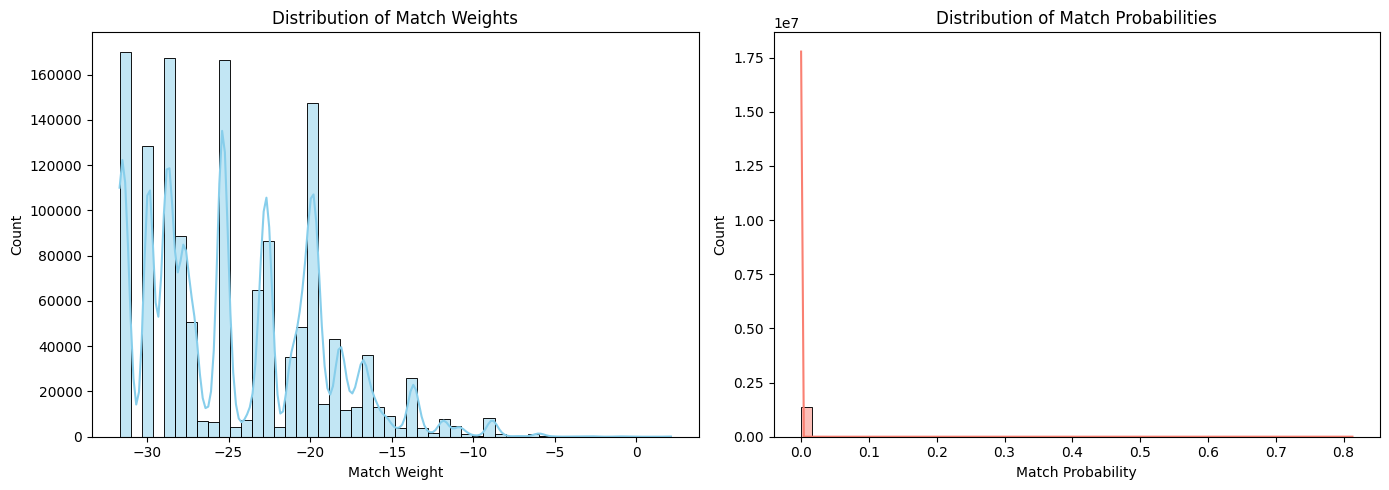

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the Splink object is converted to a Pandas DataFrame
df_pandas = df_predict.as_pandas_dataframe()

# Create a two-panel distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution (Linear scale, e.g., -10 to +30)
sns.histplot(data=df_pandas, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=df_pandas, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()


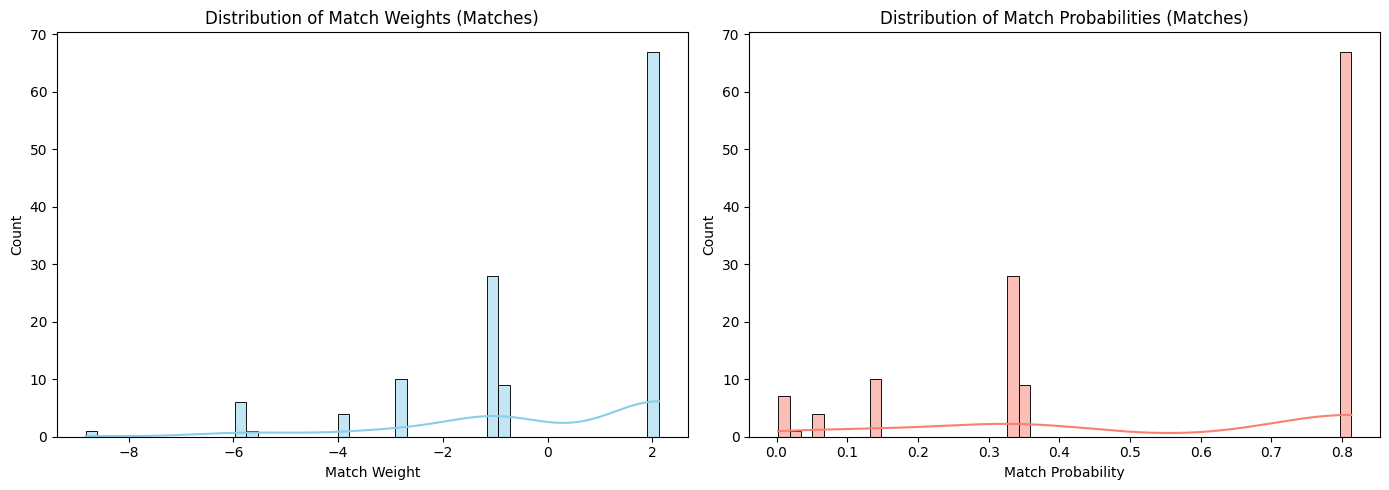

In [20]:
# We want to do the following analysis: check the distribution of match probabilities for pairs where the latent_event_id matches vs. those where it does not match.
df_predict_pd = df_predict.as_pandas_dataframe()

matches = df_predict_pd[df_predict_pd["latent_event_id_l"] == df_predict_pd["latent_event_id_r"]]
non_matches = df_predict_pd[df_predict_pd["latent_event_id_l"] != df_predict_pd["latent_event_id_r"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution
sns.histplot(data=matches, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights (Matches)")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=matches, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities (Matches)")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()

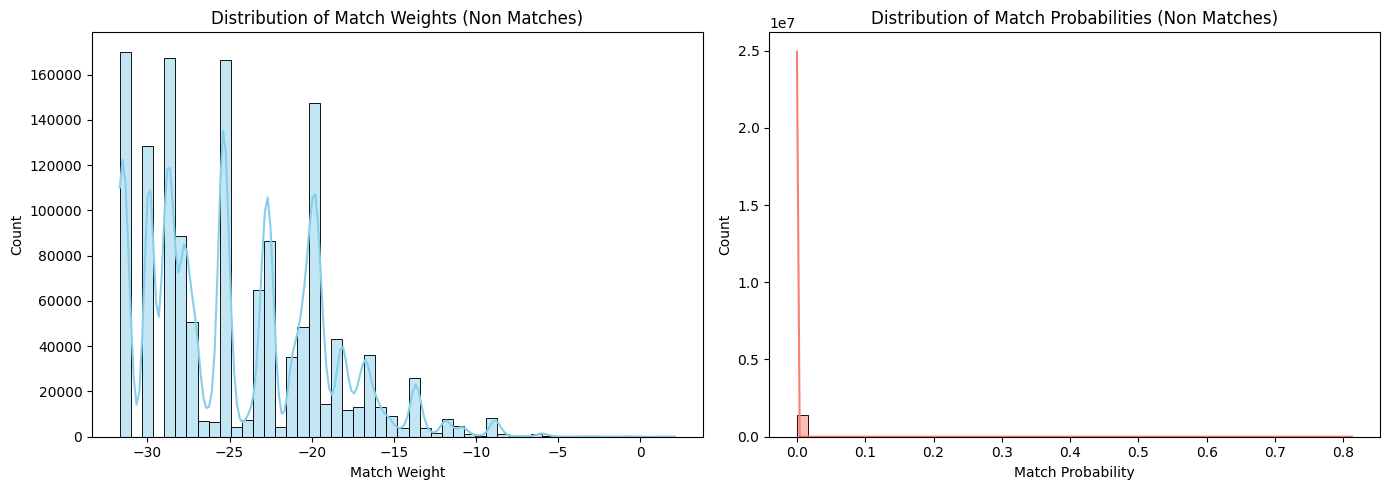

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=non_matches, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights (Non Matches)")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=non_matches, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities (Non Matches)")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import numpy as np

# 1. Gather all unique event IDs present across both sides
all_ids = pd.Series(
    list(set(df1["latent_event_id"]).union(set(df2["latent_event_id"])))
).to_frame(name="latent_event_id")

# 2. Build the true positive matches
# We force "df1" to always align as '_l' and "df2" to always align as '_r'
# If alphabetical sorting varies, we'll fix it in step 3
true_matches = all_ids.copy()
true_matches["source_dataset_l"] = "df1"
true_matches["source_dataset_r"] = "df2"
true_matches["latent_event_id_l"] = true_matches["latent_event_id"]
true_matches["latent_event_id_r"] = true_matches["latent_event_id"]
true_matches["clerical_match_score"] = 1.0

# 4. CRITICAL STEP: Correct the Left vs Right sorting assignment
# Splink mandates that CONCAT(source, '-__-', id)_l < CONCAT(source, '-__-', id)_r
# If this condition isn't true for a row, we must swap the '_l' and '_r' values.
concat_l = true_matches["source_dataset_l"] + "-__-" + true_matches["latent_event_id_l"].astype(str)
concat_r = true_matches["source_dataset_r"] + "-__-" + true_matches["latent_event_id_r"].astype(str)
should_swap = concat_l > concat_r

# Swap elements where the sorting condition is violated
true_matches.loc[should_swap, ["source_dataset_l", "source_dataset_r"]] = \
    true_matches.loc[should_swap, ["source_dataset_r", "source_dataset_l"]].values

true_matches.loc[should_swap, ["latent_event_id_l", "latent_event_id_r"]] = \
    true_matches.loc[should_swap, ["latent_event_id_r", "latent_event_id_l"]].values

# 5. Extract only the columns required by Splink
labels_df = true_matches[[
    "source_dataset_l", "source_dataset_r", 
    "latent_event_id_l", "latent_event_id_r", 
    "clerical_match_score"
]].copy()

# 6. Re-register with the overwrite flag enabled
try:
    linker.misc.query_sql("DROP TABLE IF EXISTS my_ground_truth_labels")
except Exception:
    pass

labels_table = linker.table_management.register_labels_table(
    labels_df, 
    overwrite=True
)


'CREATE TABLE __splink__df_sql_query_d61326fff AS 
DROP TABLE IF EXISTS my_ground_truth_labels' contains unsupported syntax. Falling back to parsing as a 'Command'.


In [23]:
import pandas as pd

# ==========================================
# STEP 1: Discover Splink's Internal Dataset Names
# ==========================================
# Get the exact keys Splink uses internally to label the left and right datasets
dataset_names = list(linker._input_tables_dict.keys())
print(f"DEBUG: Splink recognizes your datasets as: {dataset_names}")

# Assign them cleanly based on their registration sequence
internal_name_df1 = dataset_names[0]
internal_name_df2 = dataset_names[1]


# ==========================================
# STEP 2: Standardise and Extract Common Identifiers
# ==========================================
# Get common IDs and ensure they are read purely as identical string types
ids_df1 = df1[['latent_event_id']].copy().rename(columns={'latent_event_id': 'latent_event_id_l'})
ids_df2 = df2[['latent_event_id']].copy().rename(columns={'latent_event_id': 'latent_event_id_r'})

raw_matches = ids_df1.merge(ids_df2, left_on='latent_event_id_l', right_on='latent_event_id_r')


# ==========================================
# STEP 3: Enforce Exact Splink Alphabetical Left-Right Sort Order
# ==========================================
labels_df = pd.DataFrame()
labels_df["latent_event_id_l"] = raw_matches["latent_event_id_l"]
labels_df["latent_event_id_r"] = raw_matches["latent_event_id_r"]
labels_df["source_dataset_l"] = internal_name_df1
labels_df["source_dataset_r"] = internal_name_df2
labels_df["clerical_match_score"] = 1.0

# Splink drops labels if concat(source_l, id_l) > concat(source_r, id_r)
concat_l = labels_df["source_dataset_l"] + "-__-" + labels_df["latent_event_id_l"]
concat_r = labels_df["source_dataset_r"] + "-__-" + labels_df["latent_event_id_r"]
swap_mask = concat_l > concat_r

if swap_mask.any():
    # Correct source datasets orientation
    labels_df.loc[swap_mask, ["source_dataset_l", "source_dataset_r"]] = \
        labels_df.loc[swap_mask, ["source_dataset_r", "source_dataset_l"]].values
    # Correct corresponding ID orientation
    labels_df.loc[swap_mask, ["latent_event_id_l", "latent_event_id_r"]] = \
        labels_df.loc[swap_mask, ["latent_event_id_r", "latent_event_id_l"]].values


# ==========================================
# STEP 4: Safely Overwrite and Register Table Pointers
# ==========================================
try:
    linker.misc.query_sql("DROP TABLE IF EXISTS my_ground_truth_labels")
except Exception:
    pass

labels_table = linker.table_management.register_labels_table(labels_df, overwrite=True)
print(f"Success: Registered {len(labels_df)} ground-truth rows with Splink's structural format.")


# ==========================================
# STEP 5: Force Prediction & Extract Accuracy Metrics
# ==========================================
# Ensure a prediction pass has run so intermediate tables are active
print("Calculating link pairs...")
pred = linker.inference.predict() 

# Extract the metrics
try:
    roc_metrics_df = linker.evaluation.accuracy_analysis_from_labels_table(
        labels_table, 
        output_type="table",
        add_metrics=["f1", "accuracy"]
    ).as_pandas_dataframe()
    
    print(f"Evaluation succeeded! Rows generated: {len(roc_metrics_df)}")
except Exception as err:
    print(f"Failed during evaluation compilation: {err}")


'CREATE TABLE __splink__df_sql_query_d61326fff AS 
DROP TABLE IF EXISTS my_ground_truth_labels' contains unsupported syntax. Falling back to parsing as a 'Command'.


DEBUG: Splink recognizes your datasets as: ['__splink__input_table_0', '__splink__input_table_1']
Success: Registered 126 ground-truth rows with Splink's structural format.
Calculating link pairs...


Blocking time: 2.04 seconds
Predict time: 0.11 seconds


Evaluation succeeded! Rows generated: 8


In [24]:
linker.evaluation.accuracy_analysis_from_labels_table(
    labels_table, 
    add_metrics=["f1", "accuracy"],
    output_type="threshold_selection"
)


alt.HConcatChart(...)

In [ ]:
pd_predict.to_parquet("local_predicts/smallestest_predictions.parquet", index=False)

In [26]:
# Save settings and trained parameters to disk
model_path = "../local_predicts/trained_splink_model.json"
linker.misc.save_model_to_json(model_path, overwrite=True)

{'link_type': 'link_only',
 'probability_two_random_records_match': 0.00017897422601396648,
 'retain_matching_columns': True,
 'retain_intermediate_calculation_columns': True,
 'additional_columns_to_retain': ['local_source_id', 'global_entity_id'],
 'sql_dialect': 'duckdb',
 'linker_uid': '4ou7j37d',
 'em_convergence': 0.0001,
 'max_iterations': 25,
 'bayes_factor_column_prefix': 'bf_',
 'term_frequency_adjustment_column_prefix': 'tf_',
 'comparison_vector_value_column_prefix': 'gamma_',
 'unique_id_column_name': 'latent_event_id',
 'source_dataset_column_name': 'source_dataset',
 'blocking_rules_to_generate_predictions': [{'blocking_rule': '\n    l.categorical = r.categorical \n    OR l.categorical IS NULL \n    OR r.categorical IS NULL\n',
   'sql_dialect': 'duckdb'},
  {'blocking_rule': "\n    strftime(l.datetime_noisy, '%Y%m') = strftime(r.datetime_noisy, '%Y%m')\n    OR l.datetime_noisy IS NULL \n    OR r.datetime_noisy IS NULL\n",
   'sql_dialect': 'duckdb'},
  {'blocking_rule':